# Predicting wait time from Background neuron firing

In [7]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

Import dataset:

In [3]:
pickle_file_path = 'dataset_v0.pickle'
with open(pickle_file_path, 'rb') as file:
    dataset, labels = pickle.load(file)

/var/folders/dt/crdhdml12gz3wxrz_v86_ngw0000gp/T/ipykernel_39308/3214864628.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataset, labels = pickle.load(file)


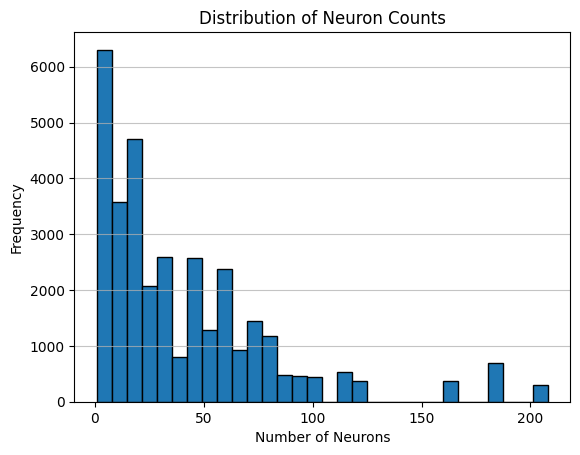

In [8]:
neuron_counts = [data.shape[0] for data in dataset]
plt.hist(neuron_counts, bins=30, edgecolor='black')
plt.title('Distribution of Neuron Counts')
plt.xlabel('Number of Neurons')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

## Naive approach, Mean Pooling and simple models

In [17]:
# Find the maximum number of rows and columns across all arrays
max_neurons = max(data.shape[0] for data in dataset)

# Pad each array with zeros to match the maximum number of neurons
padded_dataset = [np.pad(data, ((0, max_neurons - data.shape[0]), (0, 0)), mode='constant') for data in dataset]

# Stack the padded arrays along a new axis
dataset_stacked = np.stack(padded_dataset, axis=0)
print(dataset_stacked.shape)


(33462, 208, 50)


In [19]:
dataset_max_firing_rate = np.max(dataset_stacked, axis=1)
dataset_max_firing_rate.shape

(33462, 50)

In [26]:
flat_data = dataset_max_firing_rate.flatten()
len(set(flat_data))

8